<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Preset_350_microns_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_excel('/content/drive/MyDrive/preset 350 microns study.xlsx')
sheets = pd.ExcelFile('/content/drive/MyDrive/preset 350 microns study.xlsx')
sheets.sheet_names


['preop rawdata', 'postop day 1 rawdata', 'preop-postop AK']

In [3]:
df

,Name,Date,Age,Unnamed: 3,Males,Females,RE(Preop diagnosis),LE(Preop diagnosis),RE IOP,LE IOP,...,LE R1,LE R2,LE A1,RE-AL,RE-ACD,RE LT,LE-AL,LE-ACD,LE LT,IOLP
0,Deviramma,19/1/2025,55,NaN,0,1,PPC,PPC,14,12,...,NaN,NaN,NaN,23.04,3.49,4.02,NaN,NaN,NaN,21.5
1,Sakamma,19/1/2025,69,NaN,0,1,SMC,PCIOL,9,8,...,NaN,NaN,NaN,21.87,2.82,3.66,NaN,NaN,NaN,25
2,Malamma,19/1/2025,64,NaN,0,1,PCIOL,SMC,13,12,...,44.50,46.00,95.0,NaN,NaN,NaN,22.41,3.01,3.82,21.5
3,Rajkumar,21/1/2025,57,NaN,1,0,NC,NC,10,10,...,NaN,NaN,NaN,24.17,3.67,3.72,NaN,NaN,NaN,18.5
4,Chanappa,21/1/25,79,NaN,1,0,NC,PTHYSIS BULBI,9,14,...,NaN,NaN,NaN,22.84,3.32,3.83,NaN,NaN,NaN,22.5
5,Madegowda,21/1/25,77,NaN,1,0,MC,PCIOL,10,10,...,NaN,NaN,NaN,22.82,3.66,3.41,NaN,NaN,NaN,22
6,Channabasppa,21/1/25,77,NaN,1,0,PSC,PSC,10,14,...,46.00,46.75,105.0,NaN,NaN,NaN,21.81,2.87,3.74,23
7,Chikkathayamma,24/1/25,76,NaN,0,1,NSII+CC,NSI-II,11,11,...,NaN,NaN,NaN,22.55,2.83,3.65,NaN,NaN,NaN,21
8,Mahadevamma,24/1/25,79,NaN,0,1,Black cataract,NSIII+IV,11,17,...,44.50,45.25,25.0,NaN,NaN,NaN,23.22,3.29,4.17,20
9,Girijamma,24/1/25,52,NaN,0,1,PCIOL,MC,13,13,...,44.50,45.00,130.0,NaN,NaN,NaN,21.81,3.25,3.79,24.5


In [4]:
df['Age'].describe()

,Age
count,42.000000
mean,67.142857
std,9.235592
min,39.000000
25%,60.500000
50%,65.000000
75%,75.500000
max,82.000000


<Axes: >

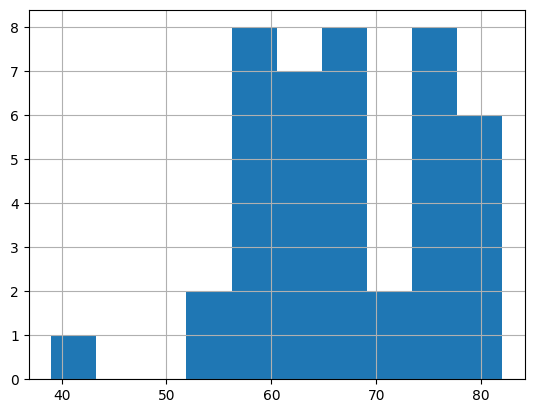

In [5]:
df['Age'].hist()

<Axes: >

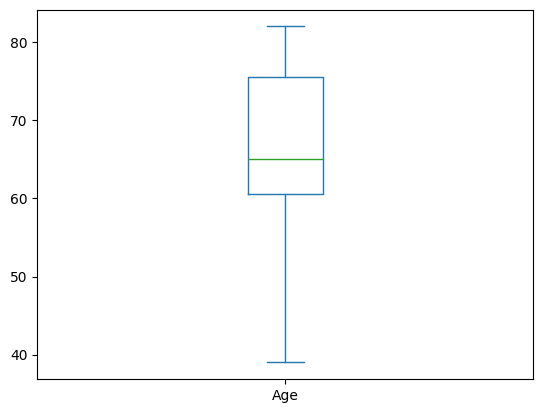

In [6]:
df['Age'].plot.box()

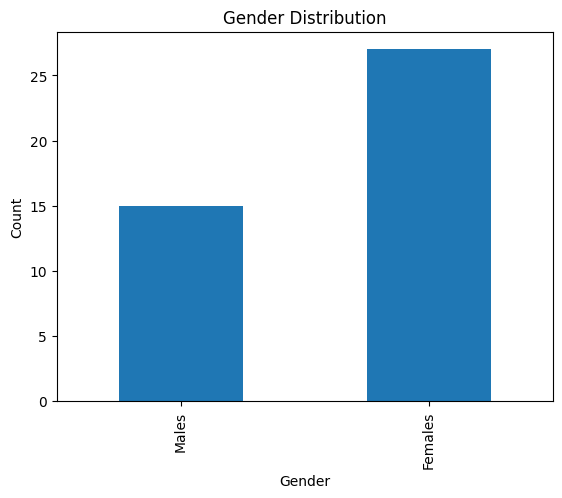

In [7]:
import matplotlib.pyplot as plt

gender_counts = df[['Males', 'Females']].sum()
gender_counts.plot(kind='bar', title='Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [8]:
gender_percentage = (gender_counts / gender_counts.sum()) * 100
print(gender_percentage)

Males      35.714286
Females    64.285714
dtype: float64


In [9]:
df.groupby(['Males', 'Females']).describe()

Age                                                     \
              count       mean       std   min   25%   50%   75%   max   
Males Females                                                            
0     1        27.0  65.814815  9.021500  39.0  60.5  65.0  73.0  79.0   
1     0        15.0  69.533333  9.440541  57.0  61.5  64.0  78.0  82.0   

              Unnamed: 3       ...  LE-ACD       LE LT                     \
                   count mean  ...     75%   max count     mean       std   
Males Females                  ...                                          
0     1              0.0  NaN  ...  3.4750  3.49   8.0  3.85875  0.328218   
1     0              0.0  NaN  ...  3.6275  3.72   8.0  3.69625  0.262349   

                                                
                min     25%    50%   75%   max  
Males Females                                   
0     1        3.40  3.7050  3.805  4.18  4.24  
1     0        3.28  3.6275  3.800  3.85  3.96  

[2 rows x 128 columns]

In [10]:
from scipy.stats import chi2_contingency

# Create age groups
bins = [0, 60, 70, 80, 90]
labels = ['<60', '60-70', '70-80', '>80']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Create a contingency table
contingency_table = pd.crosstab(df['Males'], df['age_group'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 6.253348974917603
p-value: 0.09991418168804232


In [11]:
from scipy.stats import ttest_ind

# Separate 'Age' for males and females
males_age = df[df['Males'] == 1]['Age']
females_age = df[df['Females'] == 1]['Age']

# Perform independent t-test for Age
t_stat_age, p_val_age = ttest_ind(males_age, females_age, nan_policy='omit')

print("Independent t-test for Age between genders:")
print("t-statistic:", t_stat_age)
print("p-value:", p_val_age)

Independent t-test for Age between genders:
t-statistic: 1.2591783543464743
p-value: 0.21526462430462526


In [14]:
rawdata = sheets.parse('preop rawdata')
rawdata.head()

,Name,Date,Age,Unnamed: 3,Males,Females,RE(Preop diagnosis),LE(Preop diagnosis),RE IOP,LE IOP,...,LE R1,LE R2,LE A1,RE-AL,RE-ACD,RE LT,LE-AL,LE-ACD,LE LT,IOLP
0,Deviramma,19/1/2025,55,NaN,0,1,PPC,PPC,14,12,...,NaN,NaN,NaN,23.04,3.49,4.02,NaN,NaN,NaN,21.5
1,Sakamma,19/1/2025,69,NaN,0,1,SMC,PCIOL,9,8,...,NaN,NaN,NaN,21.87,2.82,3.66,NaN,NaN,NaN,25
2,Malamma,19/1/2025,64,NaN,0,1,PCIOL,SMC,13,12,...,44.5,46.0,95.0,NaN,NaN,NaN,22.41,3.01,3.82,21.5
3,Rajkumar,21/1/2025,57,NaN,1,0,NC,NC,10,10,...,NaN,NaN,NaN,24.17,3.67,3.72,NaN,NaN,NaN,18.5
4,Chanappa,21/1/25,79,NaN,1,0,NC,PTHYSIS BULBI,9,14,...,NaN,NaN,NaN,22.84,3.32,3.83,NaN,NaN,NaN,22.5


In [16]:
prepostak = sheets.parse('preop-postop AK')
prepostak

,Name,prekh,prekv,prea1,postkh,postkv,posta2
0,Deviramma,43.50,43.75,35,43.25,43.250,180
1,Sakamma,43.00,44.00,75,43.25,43.750,135
2,Malamma,44.50,46.00,95,45.25,48.500,180
3,Rajkumar,43.25,44.50,60,43.00,44.750,60
4,Chanappa,42.25,43.75,100,43.00,43.250,120
5,Madegowda,43.00,44.50,80,42.25,45.000,85
6,Channabasppa,46.00,46.75,105,43.75,50.509,25
7,Chikkathayamma,44.25,46.50,55,46.75,48.250,170
8,Mahadevamma,44.50,45.25,25,44.75,46.250,160
9,Girijamma,44.50,45.00,130,45.00,45.500,90


In [17]:
prepostak.shape,prepostak.columns

((42, 7),
 Index(['Name', 'prekh', 'prekv', 'prea1', 'postkh', 'postkv', 'posta2'], dtype='object'))

In [18]:
prepostak.describe()

,prekh,prekv,prea1,postkh,postkv,posta2
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,43.988095,44.869048,86.071429,43.791667,45.839500,98.452381
std,1.591663,1.549231,38.785459,1.863413,2.423521,55.584347
min,40.250000,40.750000,5.000000,37.750000,38.500000,10.000000
25%,42.750000,43.812500,65.000000,42.562500,44.312500,60.000000
50%,43.875000,44.500000,87.500000,43.750000,46.250000,90.000000
75%,45.250000,46.187500,110.000000,44.937500,47.250000,145.000000
max,47.000000,47.500000,170.000000,47.000000,50.750000,180.000000


In [19]:
prepostak_clean = prepostak.drop('Name',axis=1)
prepostak_clean.describe()

,prekh,prekv,prea1,postkh,postkv,posta2
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,43.988095,44.869048,86.071429,43.791667,45.839500,98.452381
std,1.591663,1.549231,38.785459,1.863413,2.423521,55.584347
min,40.250000,40.750000,5.000000,37.750000,38.500000,10.000000
25%,42.750000,43.812500,65.000000,42.562500,44.312500,60.000000
50%,43.875000,44.500000,87.500000,43.750000,46.250000,90.000000
75%,45.250000,46.187500,110.000000,44.937500,47.250000,145.000000
max,47.000000,47.500000,170.000000,47.000000,50.750000,180.000000


In [20]:
prepostak_clean.isnull().sum()

,0
prekh,0
prekv,0
prea1,0
postkh,0
postkv,0
posta2,0


In [21]:
prepostak_clean.corr()

,prekh,prekv,prea1,postkh,postkv,posta2
prekh,1.000000,0.938398,-0.009172,0.806587,0.635851,0.076634
prekv,0.938398,1.000000,-0.026529,0.871098,0.685391,0.032285
prea1,-0.009172,-0.026529,1.000000,-0.033536,0.027544,-0.286856
postkh,0.806587,0.871098,-0.033536,1.000000,0.696536,0.013589
postkv,0.635851,0.685391,0.027544,0.696536,1.000000,-0.121509
posta2,0.076634,0.032285,-0.286856,0.013589,-0.121509,1.000000


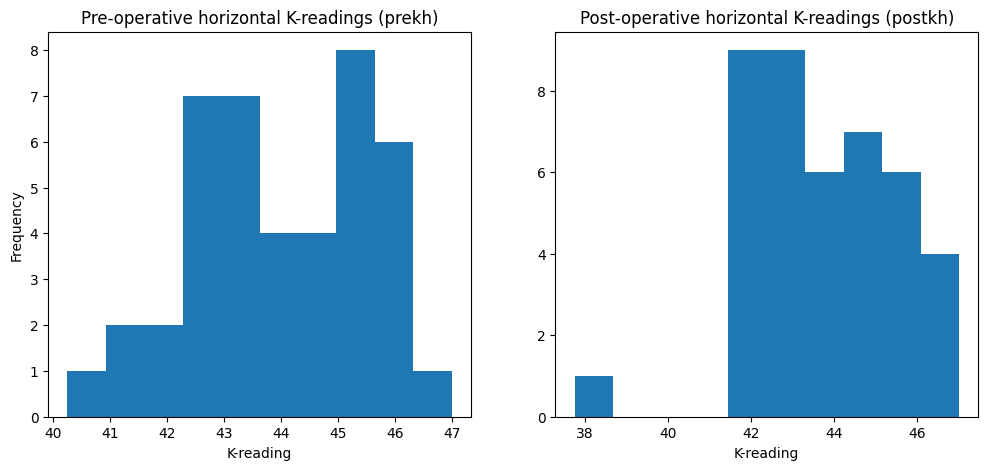

In [23]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(prepostak_clean['prekh'])
ax1.set_title('Pre-operative horizontal K-readings (prekh)')
ax1.set_xlabel('K-reading')
ax1.set_ylabel('Frequency')

ax2.hist(prepostak_clean['postkh'])
ax2.set_title('Post-operative horizontal K-readings (postkh)')
ax2.set_xlabel('K-reading')

plt.show()

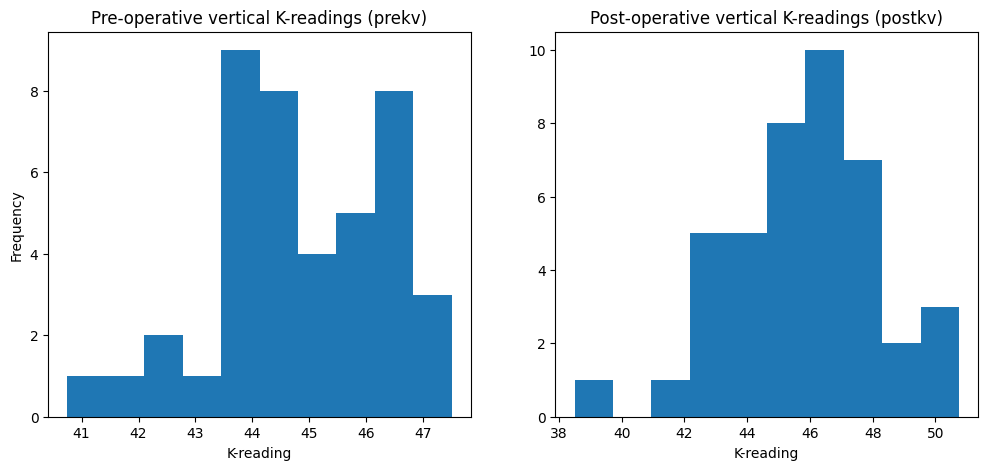

In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(prepostak_clean['prekv'])
ax1.set_title('Pre-operative vertical K-readings (prekv)')
ax1.set_xlabel('K-reading')
ax1.set_ylabel('Frequency')

ax2.hist(prepostak_clean['postkv'])
ax2.set_title('Post-operative vertical K-readings (postkv)')
ax2.set_xlabel('K-reading')

plt.show()

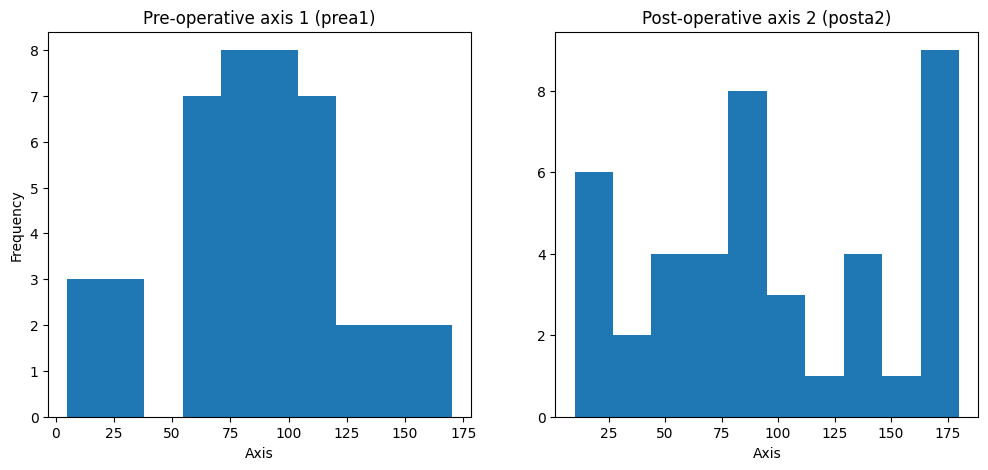

In [26]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(prepostak_clean['prea1'])
ax1.set_title('Pre-operative axis 1 (prea1)')
ax1.set_xlabel('Axis')
ax1.set_ylabel('Frequency')

ax2.hist(prepostak_clean['posta2'])
ax2.set_title('Post-operative axis 2 (posta2)')
ax2.set_xlabel('Axis')

plt.show()

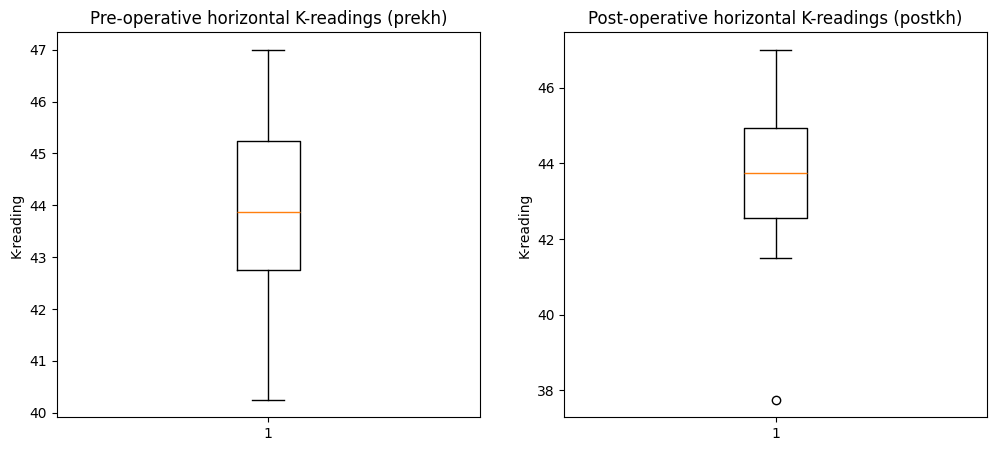

In [27]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.boxplot(prepostak_clean['prekh'])
ax1.set_title('Pre-operative horizontal K-readings (prekh)')
ax1.set_ylabel('K-reading')

ax2.boxplot(prepostak_clean['postkh'])
ax2.set_title('Post-operative horizontal K-readings (postkh)')
ax2.set_ylabel('K-reading')

plt.show()

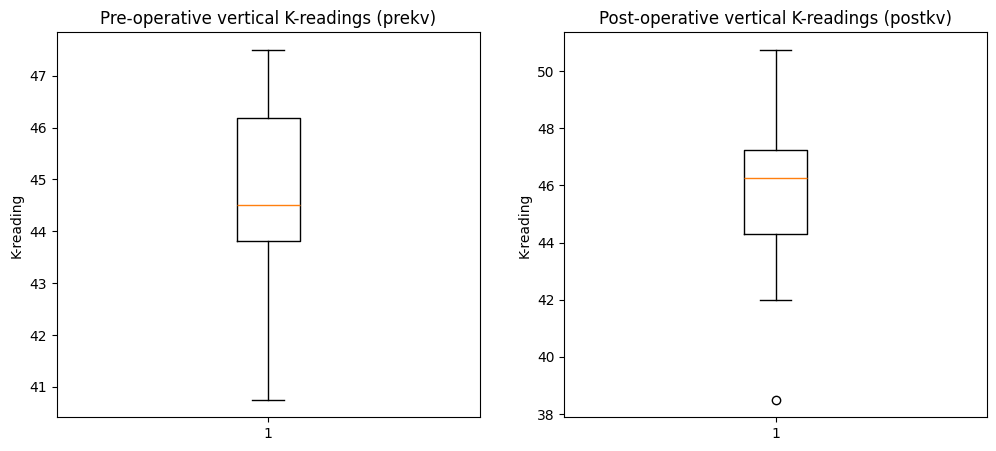

In [28]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.boxplot(prepostak_clean['prekv'])
ax1.set_title('Pre-operative vertical K-readings (prekv)')
ax1.set_ylabel('K-reading')

ax2.boxplot(prepostak_clean['postkv'])
ax2.set_title('Post-operative vertical K-readings (postkv)')
ax2.set_ylabel('K-reading')

plt.show()

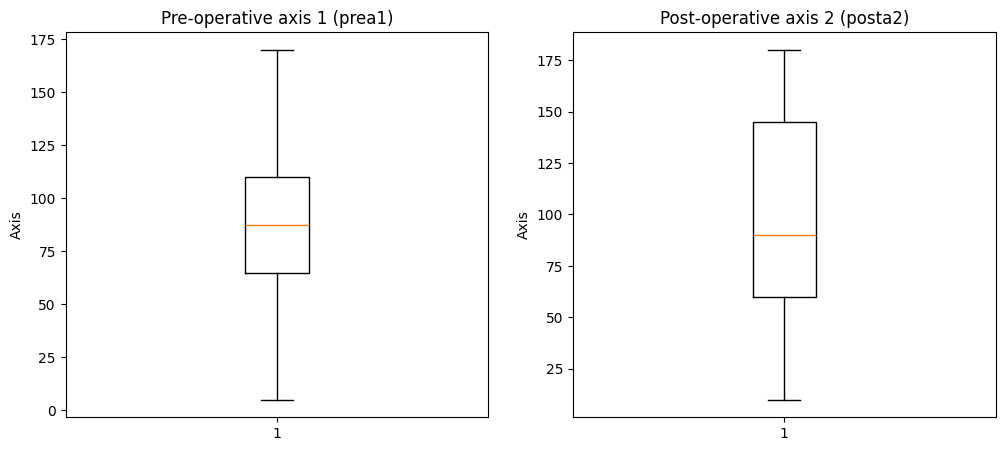

In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.boxplot(prepostak_clean['prea1'])
ax1.set_title('Pre-operative axis 1 (prea1)')
ax1.set_ylabel('Axis')

ax2.boxplot(prepostak_clean['posta2'])
ax2.set_title('Post-operative axis 2 (posta2)')
ax2.set_ylabel('Axis')

plt.show()

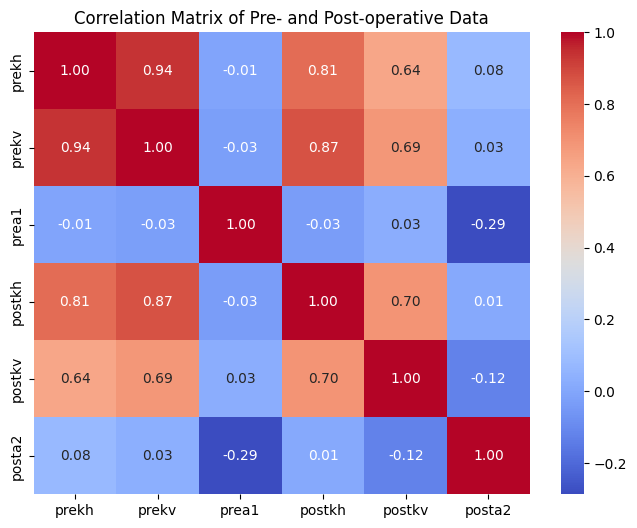

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(prepostak_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pre- and Post-operative Data')
plt.show()

In [31]:
prepostak_clean.columns

Index(['prekh', 'prekv', 'prea1', 'postkh', 'postkv', 'posta2'], dtype='object')

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = prepostak_clean[['prekh']]
y = prepostak_clean['postkh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x + ' + str(model.intercept_))

R-squared: 0.64
Root Mean Squared Error: 1.23
Mean squared error: 1.52
y = 0.855343179843614x + 6.2214378801042685


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = prepostak_clean[['prekv']]
y = prepostak_clean['postkv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x + ' + str(model.intercept_))

R-squared: 0.19
Root Mean Squared Error: 2.48
Mean squared error: 6.16
y = 1.1958370662072362x + -7.929851710558708


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = prepostak_clean[['prea1']]
y = prepostak_clean['posta2']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x + ' + str(model.intercept_))

R-squared: -0.32
Root Mean Squared Error: 42.72
Mean squared error: 1825.07
y = -0.4570272572402043x + 132.92106757524135


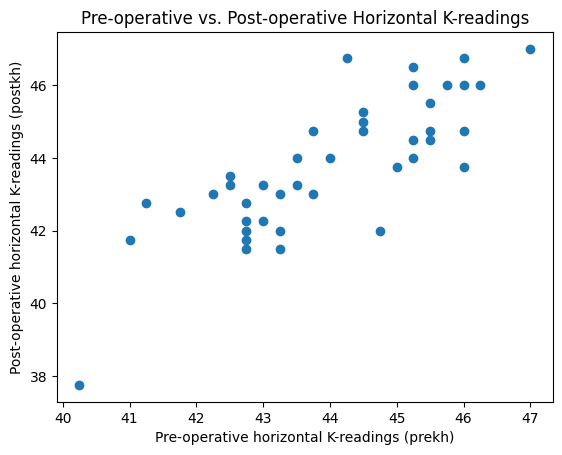

In [48]:
import matplotlib.pyplot as plt

plt.scatter(prepostak_clean['prekh'], prepostak_clean['postkh'])
plt.title('Pre-operative vs. Post-operative Horizontal K-readings')
plt.xlabel('Pre-operative horizontal K-readings (prekh)')
plt.ylabel('Post-operative horizontal K-readings (postkh)')
plt.show()

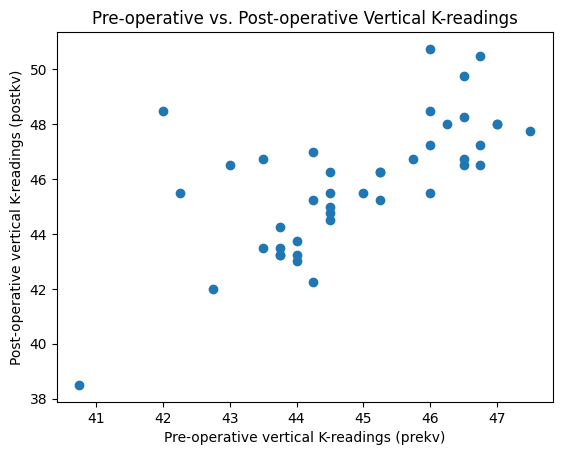

In [51]:
import matplotlib.pyplot as plt

plt.scatter(prepostak_clean['prekv'], prepostak_clean['postkv'])
plt.title('Pre-operative vs. Post-operative Vertical K-readings')
plt.xlabel('Pre-operative vertical K-readings (prekv)')
plt.ylabel('Post-operative vertical K-readings (postkv)')
plt.show()

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = prepostak_clean[['prekv']]
y = prepostak_clean['postkv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x + ' + str(model.intercept_))

R-squared: 0.19
Root Mean Squared Error: 2.48
Mean squared error: 6.16
y = 1.1958370662072362x + -7.929851710558708


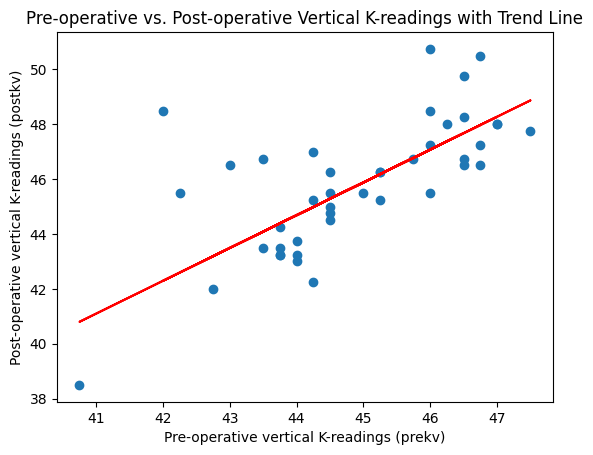

In [53]:
import matplotlib.pyplot as plt

plt.scatter(prepostak_clean['prekv'], prepostak_clean['postkv'])
plt.plot(X, model.predict(X), color='red')
plt.title('Pre-operative vs. Post-operative Vertical K-readings with Trend Line')
plt.xlabel('Pre-operative vertical K-readings (prekv)')
plt.ylabel('Post-operative vertical K-readings (postkv)')
plt.show()

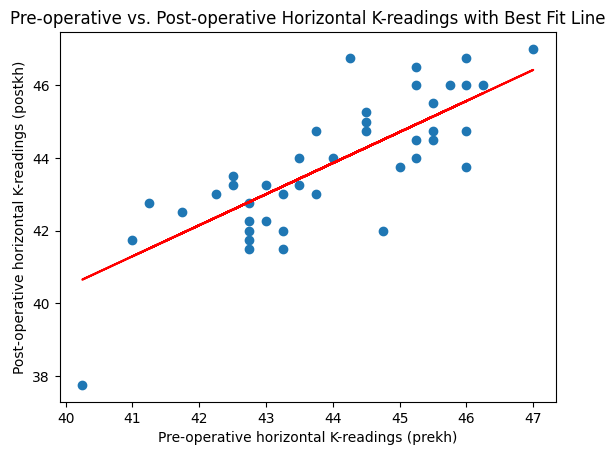

In [54]:
import matplotlib.pyplot as plt

X = prepostak_clean[['prekh']]
y = prepostak_clean['postkh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


plt.scatter(prepostak_clean['prekh'], prepostak_clean['postkh'])
plt.plot(X, model.predict(X), color='red')
plt.title('Pre-operative vs. Post-operative Horizontal K-readings with Best Fit Line')
plt.xlabel('Pre-operative horizontal K-readings (prekh)')
plt.ylabel('Post-operative horizontal K-readings (postkh)')
plt.show()

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = prepostak_clean[['prea1']]
y = prepostak_clean['posta2']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x + ' + str(model.intercept_))

R-squared: -0.32
Root Mean Squared Error: 42.72
Mean squared error: 1825.07
y = -0.4570272572402043x + 132.92106757524135


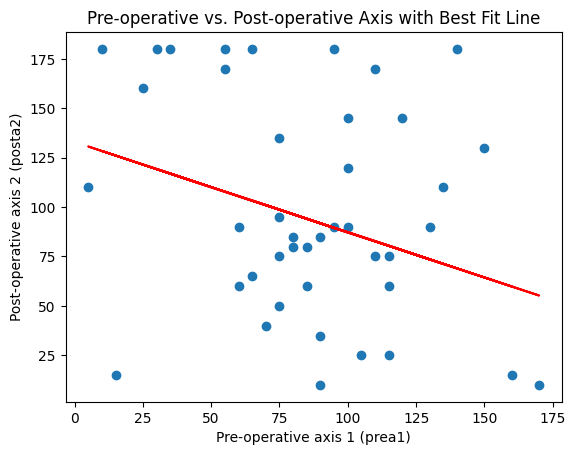

In [56]:
import matplotlib.pyplot as plt

plt.scatter(prepostak_clean['prea1'], prepostak_clean['posta2'])
plt.plot(X, model.predict(X), color='red')
plt.title('Pre-operative vs. Post-operative Axis with Best Fit Line')
plt.xlabel('Pre-operative axis 1 (prea1)')
plt.ylabel('Post-operative axis 2 (posta2)')
plt.show()

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = prepostak_clean[['prekh', 'prekv']]
y = prepostak_clean['postkh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x1 + ' + str(model.coef_[1]) + 'x2 + ' + str(model.intercept_))

R-squared: 0.75
Root Mean Squared Error: 1.02
Mean squared error: 1.04
y = -0.1293715010178936x1 + 1.168212457053817x2 + -2.963130310336048


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = prepostak_clean[['prekh', 'prekv']]
y = prepostak_clean['postkv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the coefficients
r2 = r2_score(y_test, y_pred)
print('R-squared: %.2f' % r2)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: %.2f' % rmse)

print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
print('y = ' + str(model.coef_[0]) + 'x1 + ' + str(model.coef_[1]) + 'x2 + ' + str(model.intercept_))

R-squared: 0.06
Root Mean Squared Error: 2.68
Mean squared error: 7.19
y = -0.6466232827135355x1 + 1.852068983105815x2 + -8.951753828521113


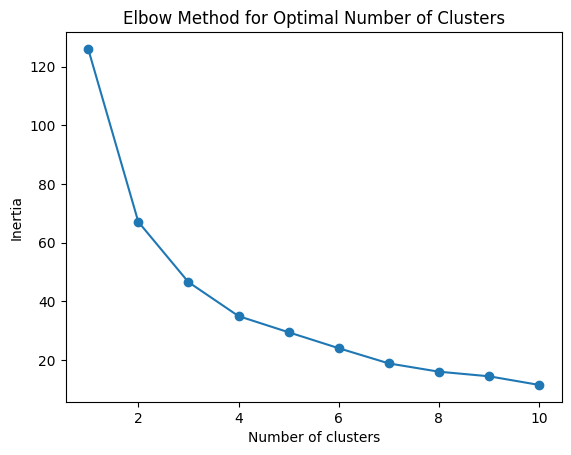

In [59]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select the pre-operative features for clustering
preop_features = prepostak_clean[['prekh', 'prekv', 'prea1']]

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(preop_features)

# Determine the optimal number of clusters using the elbow method
inertia = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

In [60]:
# Perform K-Means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
prepostak_clean['cluster'] = kmeans.fit_predict(scaled_features)

# Analyze the characteristics of each cluster
cluster_analysis = prepostak_clean.groupby('cluster').mean()
display(cluster_analysis)

,prekh,prekv,prea1,postkh,postkv,posta2
cluster,,,,,,
0,45.227273,46.045455,48.636364,44.795455,46.659091,133.181818
1,42.704545,43.681818,88.409091,42.534091,44.500000,91.590909
2,45.611111,46.333333,126.111111,45.638889,48.112111,72.777778


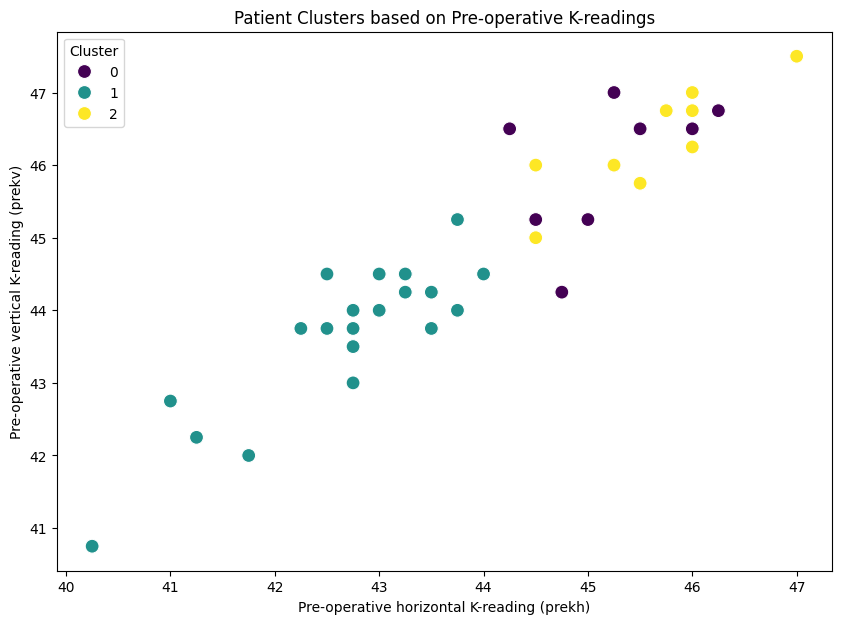

In [61]:
import seaborn as sns

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=prepostak_clean, x='prekh', y='prekv', hue='cluster', palette='viridis', s=100)
plt.title('Patient Clusters based on Pre-operative K-readings')
plt.xlabel('Pre-operative horizontal K-reading (prekh)')
plt.ylabel('Pre-operative vertical K-reading (prekv)')
plt.legend(title='Cluster')
plt.show()

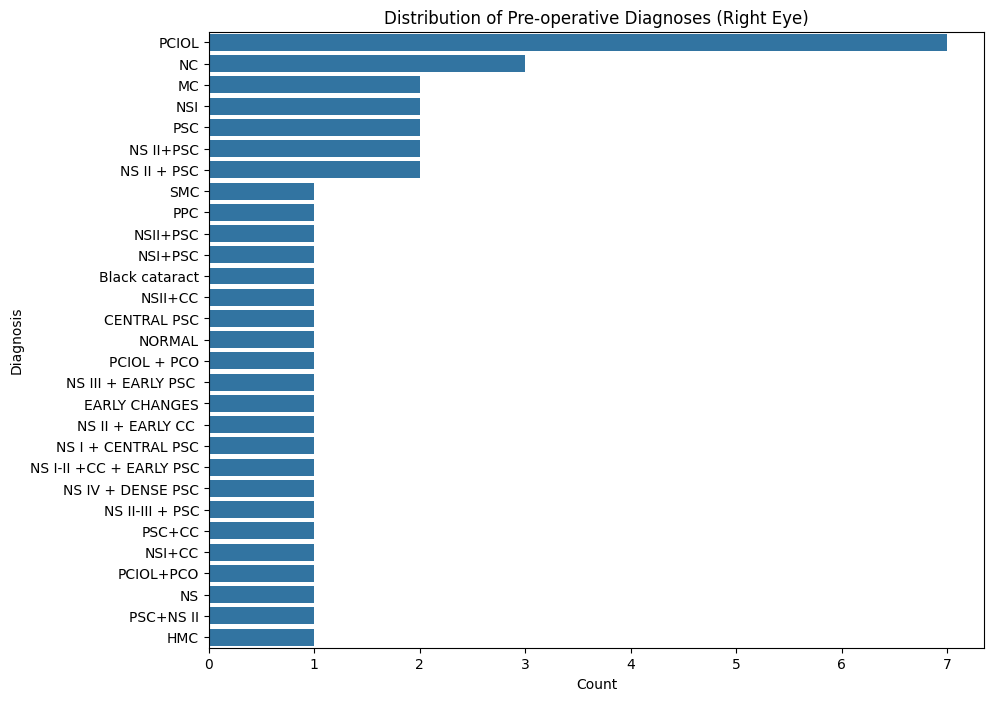

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.countplot(y='RE(Preop diagnosis)', data=rawdata, order = rawdata['RE(Preop diagnosis)'].value_counts().index)
plt.title('Distribution of Pre-operative Diagnoses (Right Eye)')
plt.xlabel('Count')
plt.ylabel('Diagnosis')
plt.show()

In [63]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the ANOVA model
model = ols('postkh ~ C(cluster)', data=prepostak_clean).fit()

# Perform the ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

               sum_sq    df          F        PR(>F)
C(cluster)  76.586490   2.0  22.704163  2.892323e-07
Residual    65.778093  39.0        NaN           NaN


In [64]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the ANOVA model for postkv
model_kv = ols('postkv ~ C(cluster)', data=prepostak_clean).fit()

# Perform the ANOVA
anova_table_kv = sm.stats.anova_lm(model_kv, typ=2)

print(anova_table_kv)

                sum_sq    df          F   PR(>F)
C(cluster)   93.345599   2.0  12.343446  0.00007
Residual    147.466052  39.0        NaN      NaN


In [65]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test for postkh
tukey_kh = pairwise_tukeyhsd(endog=prepostak_clean['postkh'],
                             groups=prepostak_clean['cluster'],
                             alpha=0.05)

# Display the results
print("Tukey's HSD for Post-operative Horizontal K-readings (postkh)")
print(tukey_kh)

Tukey's HSD for Post-operative Horizontal K-readings (postkh)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1  -2.2614 0.0001 -3.4298 -1.093   True
     0      2   0.8434 0.3283 -0.5787 2.2656  False
     1      2   3.1048    0.0  1.8528 4.3568   True
---------------------------------------------------


In [66]:
# Perform Tukey's HSD test for postkv
tukey_kv = pairwise_tukeyhsd(endog=prepostak_clean['postkv'],
                             groups=prepostak_clean['cluster'],
                             alpha=0.05)

# Display the results
print("\nTukey's HSD for Post-operative Vertical K-readings (postkv)")
print(tukey_kv)


Tukey's HSD for Post-operative Vertical K-readings (postkv)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -2.1591 0.0125 -3.9085 -0.4097   True
     0      2    1.453 0.2324 -0.6763  3.5824  False
     1      2   3.6121 0.0001  1.7376  5.4866   True
----------------------------------------------------
